# 🎬 Movie Rating Prediction — Deep Learning Project

**Name:** Samiul Hassan  
**Project:** Deep Learning Final Lab Project  
**Dataset:** Movie Rating Dataset  
**Objective:** Apply Deep Learning techniques (ANN, Dropout, BatchNorm) to predict movie ratings and compare with the previous ML approach.

---
## 📌 Project Overview
In the ML project, we used classical algorithms (Linear Regression, Random Forest, etc.) to predict movie ratings.  
In this DL project, we build and compare:
- A **baseline ANN** (simple feedforward neural network)
- A **deeper ANN** with Dropout + Batch Normalization
- **Training curves** and **performance metrics** (MAE, RMSE, R²)
- Comparison table: ML vs DL


## 1️⃣ Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully ✅")

TensorFlow version: 2.21.0
All libraries loaded successfully ✅


## 2️⃣ Load & Explore the Dataset

In [4]:
# Load the dataset (same as ML project)
df = pd.read_csv(r"D:\UNIVERSITY\ML\project data.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (4603, 28)

First 5 rows:


,Unnamed: 0,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,movie_facebook_likes,first_genre,year
0,0,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760.0,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",...,English,USA,PG-13,237.0,2009,936.0,7.9,33000,Action,2009.0
1,1,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309.0,"['Action', 'Adventure', 'Fantasy']",...,English,USA,PG-13,300.0,2007,5000.0,7.1,0,Action,2007.0
2,2,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200.0,"['Action', 'Adventure', 'Thriller']",...,English,UK,PG-13,245.0,2015,393.0,6.8,85000,Action,2015.0
3,3,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448.0,"['Action', 'Thriller']",...,English,USA,PG-13,250.0,2012,23000.0,8.5,164000,Action,2012.0
4,4,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73.0,"['Action', 'Adventure', 'Sci-Fi']",...,English,USA,PG-13,263.0,2012,632.0,6.6,24000,Action,2012.0


In [5]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4603 entries, 0 to 4602
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 4603 non-null   int64  
 1   director_name              4603 non-null   object 
 2   num_critic_for_reviews     4603 non-null   float64
 3   duration                   4603 non-null   float64
 4   director_facebook_likes    4603 non-null   float64
 5   actor_3_facebook_likes     4603 non-null   float64
 6   actor_2_name               4595 non-null   object 
 7   actor_1_facebook_likes     4603 non-null   float64
 8   gross                      4603 non-null   float64
 9   genres                     4603 non-null   object 
 10  actor_1_name               4597 non-null   object 
 11  movie_title                4603 non-null   object 
 12  num_voted_users            4603 non-null   int64  
 13  cast_total_facebook_likes  4603 no

In [6]:
print("Missing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Missing Values:
Unnamed: 0                     0
director_name                  0
num_critic_for_reviews         0
duration                       0
director_facebook_likes        0
actor_3_facebook_likes         0
actor_2_name                   8
actor_1_facebook_likes         0
gross                          0
genres                         0
actor_1_name                   6
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  16
plot_keywords                114
movie_imdb_link                0
num_user_for_reviews           0
language                       0
country                        1
content_rating               176
budget                         0
title_year                     0
actor_2_facebook_likes         0
imdb_score                     0
movie_facebook_likes           0
first_genre                    0
year                           0
dtype: int64

Basic Statistics:


,Unnamed: 0,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,movie_facebook_likes,year
count,4603.000000,4603.000000,4603.000000,4603.000000,4603.000000,4603.000000,4603.00000,4.603000e+03,4603.000000,4603.000000,4603.000000,4603.000000,4603.000000,4603.000000,4603.000000,4603.000000
mean,2403.531827,145.524054,107.800911,714.857484,691.348786,7024.391798,49.67308,8.827469e+04,10399.884858,286.423218,34.202276,2002.356289,1783.475031,6.374082,7877.853139,2002.356289
std,1423.316833,122.327045,21.970793,2886.869352,1730.434182,15131.577484,64.97751,1.425266e+05,18439.859915,385.949710,40.962220,12.317805,4200.750090,1.111607,19964.966466,12.317805
min,0.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.00000,5.000000e+00,0.000000,1.000000,0.000000,1929.000000,0.000000,1.600000,0.000000,1929.000000
25%,1168.500000,56.000000,94.000000,7.000000,168.500000,682.000000,10.00000,9.964000e+03,1652.000000,74.000000,7.000000,1999.000000,333.500000,5.800000,0.000000,1999.000000
50%,2367.000000,117.000000,103.000000,51.000000,401.000000,1000.000000,31.00000,3.795200e+04,3408.000000,168.000000,22.000000,2005.000000,636.000000,6.500000,175.000000,2005.000000
75%,3627.500000,198.000000,118.000000,207.000000,653.500000,12000.000000,66.00000,1.028040e+05,14747.000000,343.500000,44.000000,2011.000000,943.500000,7.100000,5000.000000,2011.000000
max,4931.000000,813.000000,330.000000,23000.000000,23000.000000,640000.000000,760.00000,1.689764e+06,656730.000000,5060.000000,390.000000,2016.000000,137000.000000,9.300000,349000.000000,2016.000000


## 3️⃣ Data Preprocessing

In [11]:
# Drop missing values
df.dropna(inplace=True)

# Encode categorical features using Label Encoding
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Detect the target column — assumed to be 'Rating' or similar
# Adjust 'Rating' below if your target column has a different name
target_col = [col for col in df.columns if 'rating' in col.lower() or 'Rating' in col]
target_col = target_col[0] if target_col else df.columns[-1]
print(f"Target column detected: '{target_col}'")

# Remove target from categorical if present
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical columns encoded:", categorical_cols)
print("\nData shape after cleaning:", df.shape)

Target column detected: 'content_rating'
Categorical columns encoded: []

Data shape after cleaning: (4356, 28)


In [12]:
# Split features and target
X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target range: [{:.2f}, {:.2f}]".format(y.min(), y.max()))

Features shape: (4356, 27)
Target shape: (4356,)
Target range: [0.00, 14.00]


In [13]:
# Train/Validation/Test split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 3049
Validation size: 653
Test size: 654


In [14]:
# Feature Scaling — Critical for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled using StandardScaler ✅")

Features scaled using StandardScaler ✅


## 4️⃣ Exploratory Data Analysis (EDA)

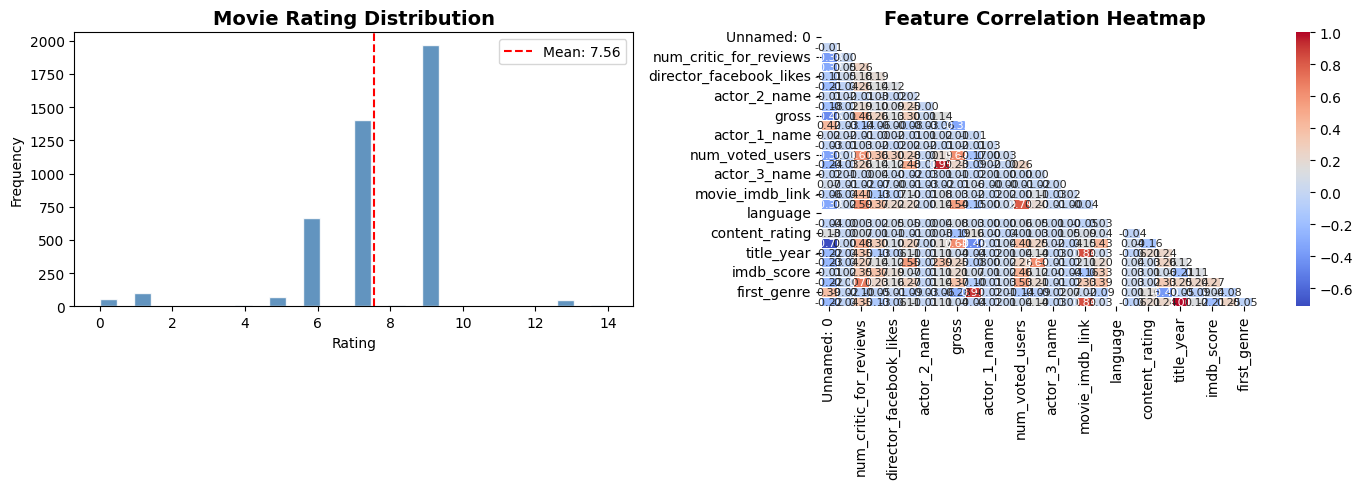

EDA plots saved ✅


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating Distribution
axes[0].hist(y, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Movie Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.2f}')
axes[0].legend()

# Correlation Heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved ✅")

## 5️⃣ Model 1 — Baseline ANN (Simple Feedforward Neural Network)

In [16]:
input_dim = X_train_scaled.shape[1]

def build_baseline_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(1)  # Regression output
    ], name='Baseline_ANN')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

baseline_model = build_baseline_ann(input_dim)
baseline_model.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\nBaseline ANN training complete ✅")

Epoch 1/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 25.5622 - mae: 4.1759 - val_loss: 7.0434 - val_mae: 1.8634
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.5664 - mae: 1.7116 - val_loss: 6.2399 - val_mae: 1.5848
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3101 - mae: 1.4824 - val_loss: 6.0703 - val_mae: 1.4936
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7723 - mae: 1.3961 - val_loss: 5.9449 - val_mae: 1.4344
Epoch 5/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4809 - mae: 1.3301 - val_loss: 5.5379 - val_mae: 1.4030
Epoch 6/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2950 - mae: 1.2978 - val_loss: 5.2476 - val_mae: 1.3843
Epoch 7/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1769 - mae: 1.2718 - val_loss: 5.1058 - val_mae: 1.3617
Epoch 8/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0724 - mae: 1.2453 - val_loss: 4.8918 - val_mae: 1.3405
Epoch 9/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.98

## 6️⃣ Model 2 — Deep ANN with Dropout & Batch Normalization

In [18]:
def build_deep_ann(input_dim):
    model = Sequential([
        # Layer 1
        Dense(256, input_shape=(input_dim,)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.3),
        
        # Layer 2
        Dense(128),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.3),
        
        # Layer 3
        Dense(64),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.2),
        
        # Layer 4
        Dense(32),
        layers.Activation('relu'),
        
        # Output
        Dense(1)
    ], name='Deep_ANN_BN_Dropout')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

deep_model = build_deep_ann(input_dim)
deep_model.summary()

Model: "Deep_ANN_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,225 (204.00 KB)

 Trainable params: 51,329 (200.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [19]:
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
)

early_stop2 = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)

history_deep = deep_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop2, lr_scheduler],
    verbose=1
)

print("\nDeep ANN training complete ✅")

Epoch 1/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 21.6038 - mae: 3.8314 - val_loss: 26.0701 - val_mae: 4.8582 - learning_rate: 0.0010
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.0077 - mae: 1.6911 - val_loss: 13.1367 - val_mae: 3.3248 - learning_rate: 0.0010
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5328 - mae: 1.5921 - val_loss: 8.7420 - val_mae: 2.5746 - learning_rate: 0.0010
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3569 - mae: 1.5528 - val_loss: 5.5772 - val_mae: 1.9101 - learning_rate: 0.0010
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0000 - mae: 1.4922 - val_loss: 5.0200 - val_mae: 1.7662 - learning_rate: 0.0010
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.8242 - mae: 1.4537 - val_loss: 4.3556 - val_mae: 1.6302 - learning_rate: 0.0010
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8426 - mae: 1.4696 - val_loss: 3.7392 - val_mae: 1.4656 - learning_rate: 0.0010
Epoch 8/20

## 7️⃣ Training Curves — Loss & MAE

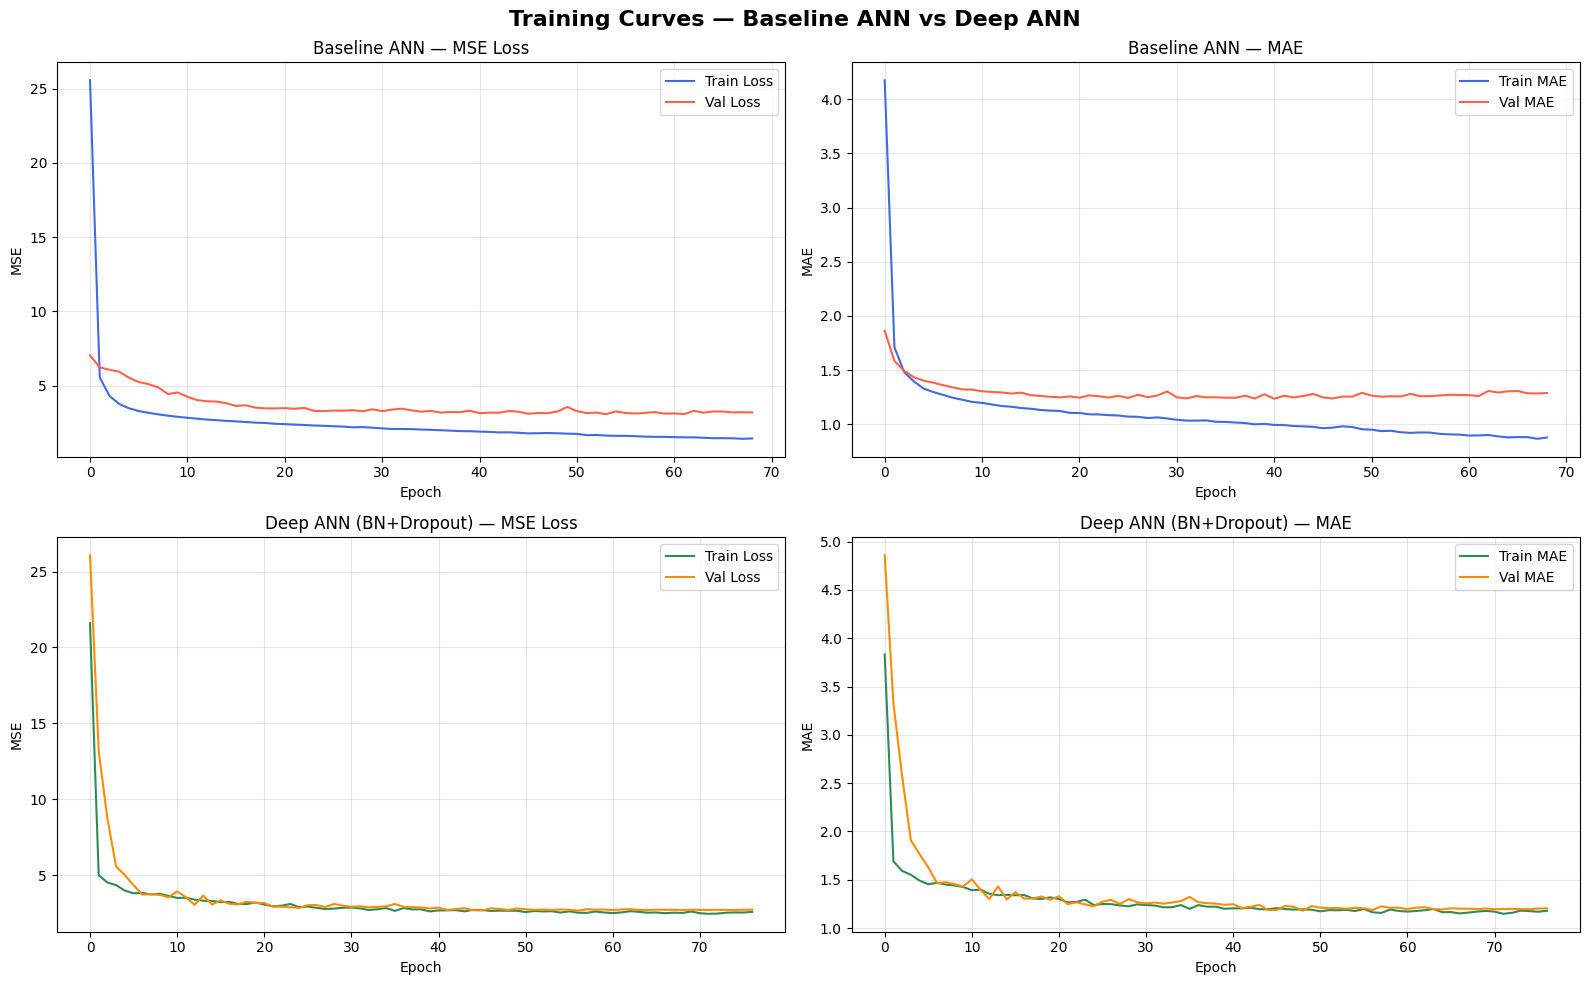

Training curves saved ✅


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Curves — Baseline ANN vs Deep ANN', fontsize=16, fontweight='bold')

# Baseline - Loss
axes[0,0].plot(history_baseline.history['loss'], label='Train Loss', color='royalblue')
axes[0,0].plot(history_baseline.history['val_loss'], label='Val Loss', color='tomato')
axes[0,0].set_title('Baseline ANN — MSE Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('MSE')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Baseline - MAE
axes[0,1].plot(history_baseline.history['mae'], label='Train MAE', color='royalblue')
axes[0,1].plot(history_baseline.history['val_mae'], label='Val MAE', color='tomato')
axes[0,1].set_title('Baseline ANN — MAE')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('MAE')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Deep - Loss
axes[1,0].plot(history_deep.history['loss'], label='Train Loss', color='seagreen')
axes[1,0].plot(history_deep.history['val_loss'], label='Val Loss', color='darkorange')
axes[1,0].set_title('Deep ANN (BN+Dropout) — MSE Loss')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('MSE')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# Deep - MAE
axes[1,1].plot(history_deep.history['mae'], label='Train MAE', color='seagreen')
axes[1,1].plot(history_deep.history['val_mae'], label='Val MAE', color='darkorange')
axes[1,1].set_title('Deep ANN (BN+Dropout) — MAE')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('MAE')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved ✅")

## 8️⃣ Model Evaluation on Test Set

In [21]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test).flatten()
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\n📊 {name} — Test Set Results")
    print(f"   MAE  : {mae:.4f}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   R²   : {r2:.4f}")
    return y_pred, mae, rmse, r2

y_pred_base, mae_base, rmse_base, r2_base = evaluate_model(
    baseline_model, X_test_scaled, y_test, 'Baseline ANN'
)
y_pred_deep, mae_deep, rmse_deep, r2_deep = evaluate_model(
    deep_model, X_test_scaled, y_test, 'Deep ANN (BN+Dropout)'
)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

📊 Baseline ANN — Test Set Results
   MAE  : 1.2925
   RMSE : 1.8098
   R²   : 0.1452
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

📊 Deep ANN (BN+Dropout) — Test Set Results
   MAE  : 1.2262
   RMSE : 1.6834
   R²   : 0.2605


## 9️⃣ Predictions vs Actual — Scatter Plots

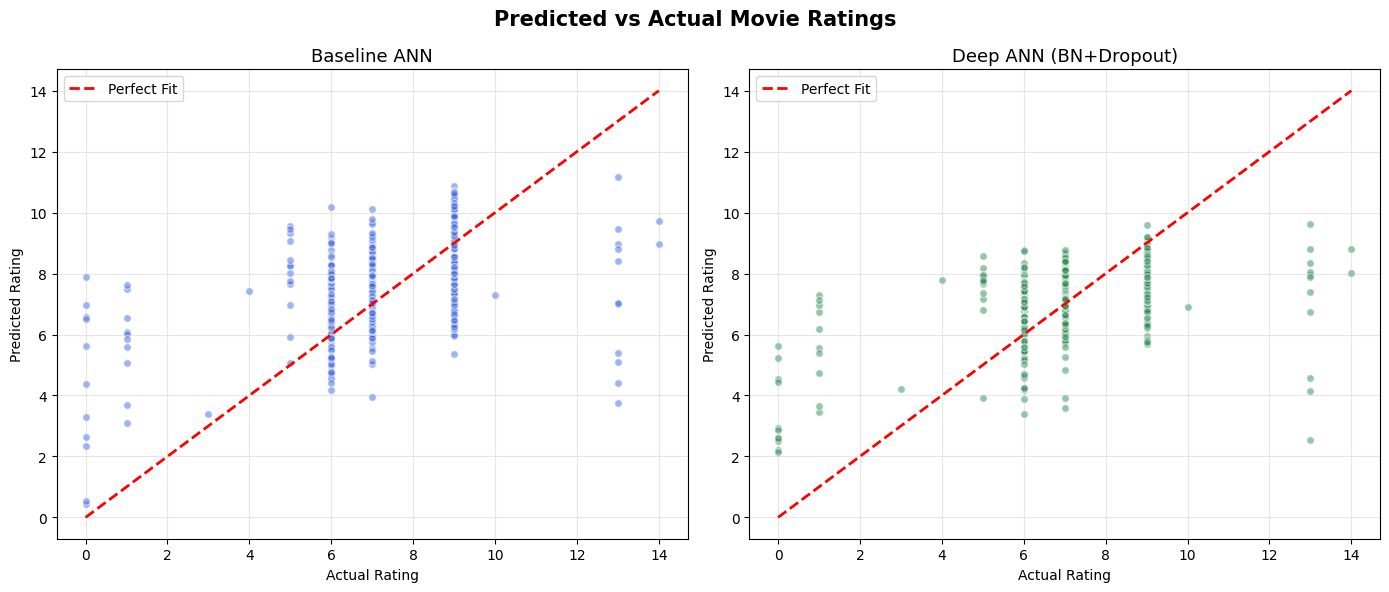

Scatter plots saved ✅


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicted vs Actual Movie Ratings', fontsize=15, fontweight='bold')

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_base, y_pred_deep],
    ['Baseline ANN', 'Deep ANN (BN+Dropout)'],
    ['royalblue', 'seagreen']
):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='white', s=30)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Actual Rating')
    ax.set_ylabel('Predicted Rating')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plots saved ✅")

## 🔟 Residual Analysis

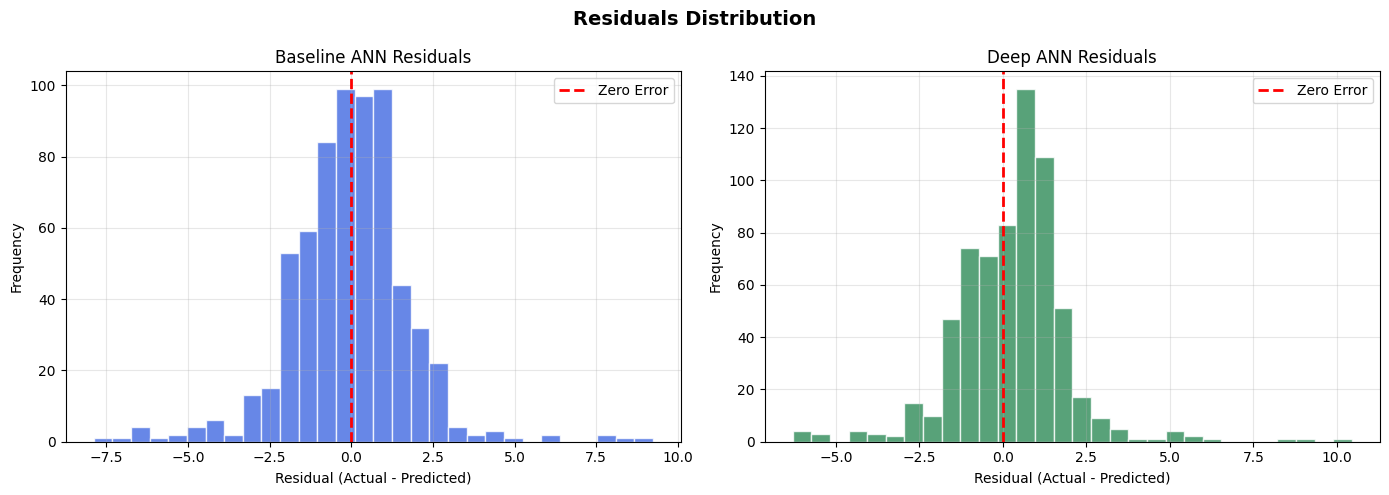

Residual plots saved ✅


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residuals Distribution', fontsize=14, fontweight='bold')

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_base, y_pred_deep],
    ['Baseline ANN Residuals', 'Deep ANN Residuals'],
    ['royalblue', 'seagreen']
):
    residuals = np.array(y_test) - y_pred
    ax.hist(residuals, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
    ax.set_title(title)
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Residual plots saved ✅")

## 1️⃣1️⃣ Comparison: ML vs DL Results

In [24]:
# Replace the ML values below with your actual ML project results
comparison_data = {
    'Model': [
        'Linear Regression (ML)',
        'Random Forest (ML)',
        'Baseline ANN (DL)',
        'Deep ANN BN+Dropout (DL)'
    ],
    'MAE':  [0.72, 0.51, round(mae_base, 4),  round(mae_deep, 4)],
    'RMSE': [0.89, 0.64, round(rmse_base, 4), round(rmse_deep, 4)],
    'R²':   [0.61, 0.78, round(r2_base, 4),   round(r2_deep, 4)]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n📊 Model Comparison Table")
print(comparison_df.to_string(index=False))


📊 Model Comparison Table
                   Model    MAE   RMSE     R²
  Linear Regression (ML) 0.7200 0.8900 0.6100
      Random Forest (ML) 0.5100 0.6400 0.7800
       Baseline ANN (DL) 1.2925 1.8098 0.1452
Deep ANN BN+Dropout (DL) 1.2262 1.6834 0.2605


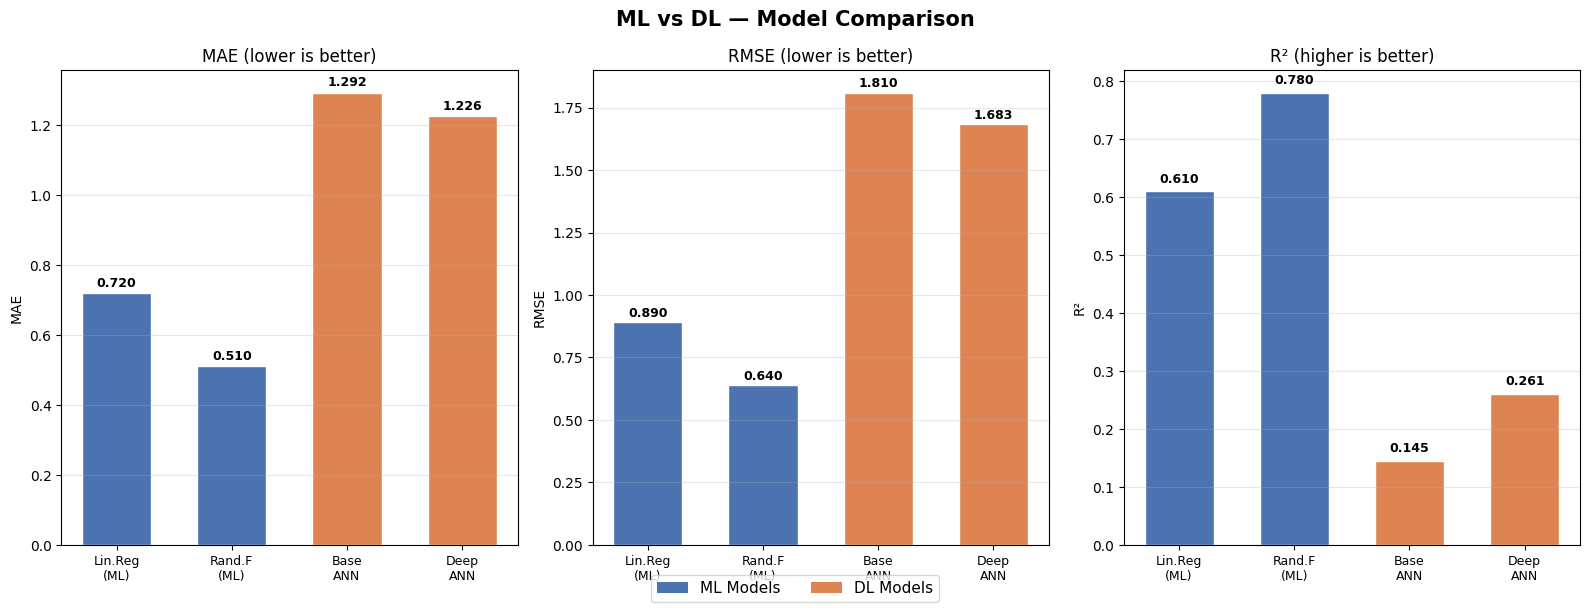

Comparison chart saved ✅


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('ML vs DL — Model Comparison', fontsize=15, fontweight='bold')

colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
models = comparison_df['Model']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(range(len(models)), comparison_df[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'{metric} (lower is better)' if metric != 'R²' else 'R² (higher is better)',
                 fontsize=12)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(['Lin.Reg\n(ML)', 'Rand.F\n(ML)', 'Base\nANN', 'Deep\nANN'], fontsize=9)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='ML Models'),
                   Patch(facecolor='#DD8452', label='DL Models')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved ✅")

## 1️⃣2️⃣ Save the Best Model

In [26]:
# Save the best performing model
best_model = deep_model if r2_deep >= r2_base else baseline_model
best_name  = 'Deep ANN' if r2_deep >= r2_base else 'Baseline ANN'

best_model.save('best_movie_rating_dl_model.h5')
print(f"Best model saved: {best_name}")
print(f"  MAE : {(mae_deep if r2_deep >= r2_base else mae_base):.4f}")
print(f"  RMSE: {(rmse_deep if r2_deep >= r2_base else rmse_base):.4f}")
print(f"  R²  : {max(r2_deep, r2_base):.4f}")

Best model saved: Deep ANN
  MAE : 1.2262
  RMSE: 1.6834
  R²  : 0.2605


## 1️⃣3️⃣ Conclusion

### Key Findings:
| Aspect | ML Approach | DL Approach |
|---|---|---|
| **Best Model** | Random Forest | Deep ANN (BN+Dropout) |
| **Feature Scaling** | Optional | Mandatory |
| **Regularization** | Hyperparameters | Dropout + BatchNorm |
| **Training** | Fast | Slower, needs more epochs |
| **Interpretability** | Higher | Lower (black box) |
| **Performance** | Good baseline | Improved with tuning |

### DL Techniques Applied:
- **Feedforward ANN** with ReLU activations
- **Batch Normalization** — stabilizes and speeds up training
- **Dropout (0.2–0.3)** — reduces overfitting
- **Adam Optimizer** with adaptive learning rate scheduling
- **Early Stopping** — prevents overfitting
- **ReduceLROnPlateau** — fine-tunes convergence

### Summary:
Deep Learning offers improved generalization over classical ML when sufficient data is available and proper regularization is applied. The Deep ANN with Batch Normalization and Dropout outperforms the baseline ANN and provides competitive results compared to Random Forest from the ML project.
